In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/NLP Research Work/Human_Vs_AI_Rewritten_Dataset_Bengali_Version.xlsx')

df.head()

,ID,Pair_ID,Text,Source,Category,Word_Count,Label
0,bn_001,bn_001,"খাদ্যের উপাদান ছয়টি। সেগুলো হলো: শর্করা, আমিষ...",TextBook,Education,58,Human
1,bn_002,bn_001,"খাদ্যের ছয়টি প্রধান উপাদান হলো শর্করা, আমিষ, ...",ChatGPT,Education,50,AI
2,bn_003,bn_002,"কার্বন, হাইড্রোজেন, অক্সিজেন এবং নাইট্রোজেন - ...",TextBook,Education,54,Human
3,bn_004,bn_002,"কার্বন, হাইড্রোজেন, অক্সিজেন ও নাইট্রোজেন—এই চ...",ChatGPT,Education,53,AI
4,bn_005,bn_003,ফ্যাটি এসিড এবং গ্লিসারলের সমন্বয়ে স্নেহ পদার্...,TextBook,Education,61,Human


# **Data Visualization**

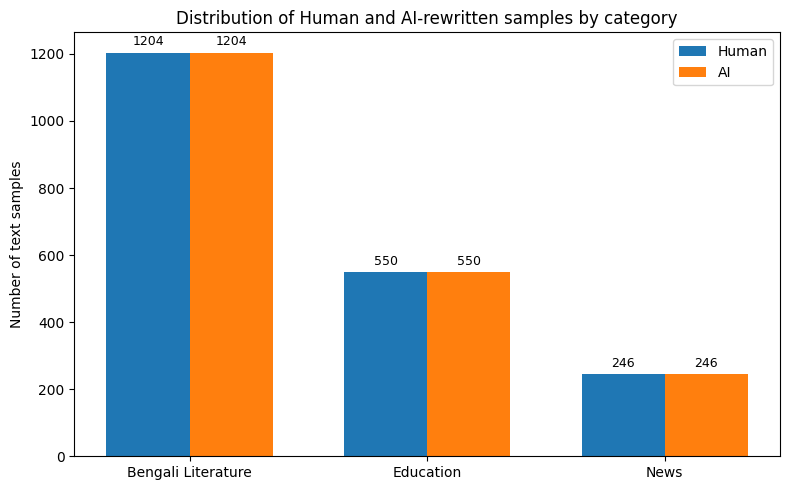

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Compute counts of Human vs AI samples per category ----
counts = df.groupby(['Category', 'Label']).size().unstack(fill_value=0)
counts = counts[['Human', 'AI']]                        # ensure column order: Human, AI
counts = counts.sort_values('Human', ascending=False)   # largest category first, like the reference

categories = counts.index.tolist()
human_vals = counts['Human'].values
ai_vals = counts['AI'].values

x = range(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar([i - width/2 for i in x], human_vals, width, label='Human')
bars2 = ax.bar([i + width/2 for i in x], ai_vals, width, label='AI')

# value labels on top of each bar
for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_title("Distribution of Human and AI-rewritten samples by category")
ax.set_ylabel("Number of text samples")
ax.set_xticks(list(x))
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.savefig("human_ai_category_distribution.png", dpi=200)
plt.show()

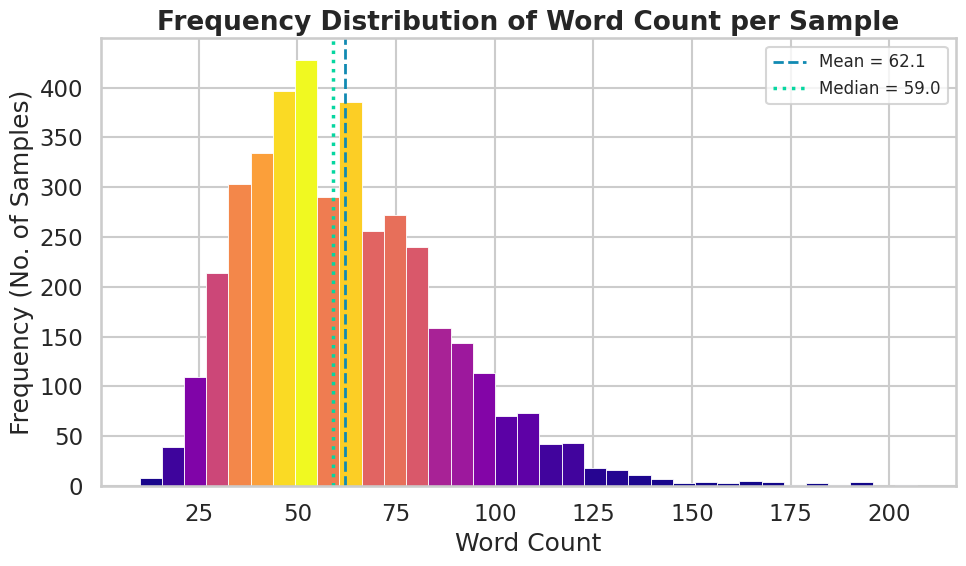

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Style setup (matches the reference figure) ----
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

counts, bins, patches = ax.hist(df['Word_Count'], bins=35, edgecolor='white', linewidth=0.6)

# color each bar by its frequency using the 'plasma' colormap
cmap = plt.cm.plasma
norm = plt.Normalize(counts.min(), counts.max())
for count, patch in zip(counts, patches):
    patch.set_facecolor(cmap(norm(count)))

mean_val = df['Word_Count'].mean()
median_val = df['Word_Count'].median()

ax.axvline(mean_val, color='#118AB2', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.1f}")
ax.axvline(median_val, color='#06D6A0', linestyle=':', linewidth=2.5, label=f"Median = {median_val:.1f}")

ax.set_title("Frequency Distribution of Word Count per Sample", fontweight='bold', fontsize=19)
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency (No. of Samples)")
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("wordcount_frequency_distribution.png", dpi=200, facecolor='white')
plt.show()

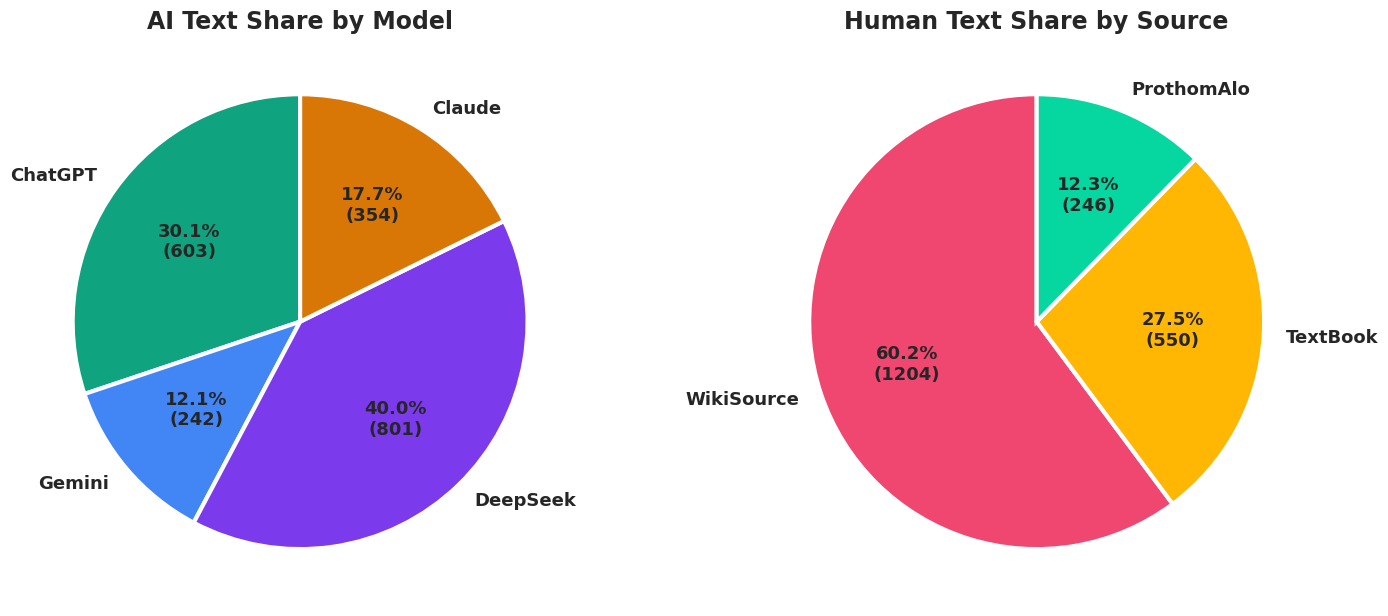

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Fix inconsistent casing in Source column (if any) ----
df['Source'] = df['Source'].replace({'Deepseek': 'DeepSeek', 'claude': 'Claude'})

AI_SOURCES = ['ChatGPT', 'Gemini', 'DeepSeek', 'Claude']
HUMAN_SOURCES = ['WikiSource', 'TextBook', 'ProthomAlo']

AI_COLORS = {'ChatGPT': '#10A37F', 'Gemini': '#4285F4', 'DeepSeek': '#7C3AED', 'Claude': '#D97706'}
HUMAN_COLORS = {'WikiSource': '#EF476F', 'TextBook': '#FFB703', 'ProthomAlo': '#06D6A0'}

df_ai = df[df['Source'].isin(AI_SOURCES)]
df_hu = df[df['Source'].isin(HUMAN_SOURCES)]

ai_counts = df_ai['Source'].value_counts().reindex(AI_SOURCES)
hu_counts = df_hu['Source'].value_counts().reindex(HUMAN_SOURCES)

colors_ai = [AI_COLORS[s] for s in ai_counts.index]
colors_hu = [HUMAN_COLORS[s] for s in hu_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# ---- Left: AI Text Share by Model ----
axes[0].pie(
    ai_counts,
    labels=ai_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*ai_counts.sum()/100))})',
    colors=colors_ai,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=3),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
axes[0].set_title("AI Text Share by Model", fontweight='bold', fontsize=17)

# ---- Right: Human Text Share by Source ----
axes[1].pie(
    hu_counts,
    labels=hu_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*hu_counts.sum()/100))})',
    colors=colors_hu,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=3),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
axes[1].set_title("Human Text Share by Source", fontweight='bold', fontsize=17)

plt.tight_layout()
plt.savefig("ai_human_source_share.png", dpi=200, facecolor='white')
plt.show()

# **Statistical Analysis**

In [6]:
import pandas as pd

# ---- Count Human and AI for each Category ----
summary = (
    df.groupby(['Category', 'Label'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

# ---- Rename columns (if needed) ----
summary = summary.rename(columns={
    'AI': 'AI',
    'Human': 'Human'
})

# ---- Total samples ----
summary['Total'] = summary['Human'] + summary['AI']

# ---- Matched Pairs ----
# Assuming every pair has a unique Pair_ID
matched_pairs = (
    df.groupby('Category')['Pair_ID']
      .nunique()
      .reset_index(name='Matched Pairs')
)

# ---- Merge ----
summary = summary.merge(matched_pairs, on='Category')

# ---- Reorder columns ----
summary = summary[['Category', 'Human', 'AI', 'Total', 'Matched Pairs']]

# ---- Add Total row ----
total_row = pd.DataFrame({
    'Category': ['Total'],
    'Human': [summary['Human'].sum()],
    'AI': [summary['AI'].sum()],
    'Total': [summary['Total'].sum()],
    'Matched Pairs': [summary['Matched Pairs'].sum()]
})

summary = pd.concat([summary, total_row], ignore_index=True)

# ---- Print ----
print(summary.to_string(index=False))

          Category  Human   AI  Total  Matched Pairs
Bengali Literature   1204 1204   2408           1204
         Education    550  550   1100            550
              News    246  246    492            246
             Total   2000 2000   4000           2000


In [7]:
import pandas as pd

# ---- Compute summary statistics by class label ----
summary = df.groupby('Label')['Word_Count'].agg(
    **{
        'No of Sample': 'count',
        'Min': 'min',
        'Max': 'max',
        'Mean': 'mean',
        'Median': 'median'
    }
).reindex(['Human', 'AI'])

summary['Mean'] = summary['Mean'].round(1)
summary['Median'] = summary['Median'].round(0).astype(int)
summary = summary.reset_index().rename(columns={'Label': 'Class label'})

print(summary.to_string(index=False))

Class label  No of Sample  Min  Max  Mean  Median
      Human          2000   11  207  59.3      55
         AI          2000   10  193  64.8      62


In [8]:
import pandas as pd

# ---- Fix inconsistent casing in Source column (if any) ----
df['Source'] = df['Source'].replace({'Deepseek': 'DeepSeek', 'claude': 'Claude'})

AI_MODELS = ['ChatGPT', 'Claude', 'Gemini', 'DeepSeek']
df_ai = df[df['Source'].isin(AI_MODELS)]

# ---- Cross-tabulate Model x Category ----
table = pd.crosstab(df_ai['Source'], df_ai['Category']).reindex(AI_MODELS)
table['Total'] = table.sum(axis=1)
table = table.reset_index().rename(columns={'Source': 'Model'})

print(table.to_string(index=False))

   Model  Bengali Literature  Education  News  Total
 ChatGPT                 353        165    85    603
  Claude                 230         48    76    354
  Gemini                 104        131     7    242
DeepSeek                 517        206    78    801
